# Study 256 -- Twitter-Mood
## For the curious: can the mood of Twitter tell you where the market goes tomorrow?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

In 2011 a paper went viral: **"Twitter mood predicts the stock market"** (Bollen, Mao
& Zeng). By scoring the *Calm* of ~10 million tweets, the authors claimed they could
forecast the Dow's next-day direction with **86.7% accuracy** -- and an entire
"social-media alpha" industry was born.

We rebuild the cleanest version of that test on the real S&P 500 tape over the exact
2008 window Bollen used, and ask the honest question: **is there a tradable mood ->
market lead-lag, or is the 87% a mirage?**


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from twitter_mood import data, strategy as st

CACHE_PATH = data.INDEX_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    df_real = data.build_real_panel(fetch=False, cache_path=CACHE_PATH)
    sweep = st.leadlag_sweep(df_real, max_lag=5)
    print(f"Real panel loaded: {len(df_real)} business days "
          f"{df_real.index[0].date()} -> {df_real.index[-1].date()}")
else:
    df_real = sweep = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 207 business days 2008-02-28 -> 2008-12-19


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_days': 207, 'window': '2008-02-28 -> 2008-12-19', 'fingerprint': 'a8dce11f0ac1', 'beta1': 0.00327, 't1': 0.9, 'r2_1': 0.0043, 'beta2': 0.00233, 't2': 0.63, 'beta3': 0.00192, 't3': 0.52, 'beta4': 0.00203, 't4': 0.56, 'beta5': 0.00244, 't5': 0.68, 'bonf_bar': 2.58, 'perm_p1': 0.35, 'perm_p2': 0.51, 'perm_p3': 0.57, 'hit_rate': 51.3, 'uncond_up': 50.8, 'edge_pts': 0.5, 'long_gross_ann': 3.9, 'long_gross_t': 0.17, 'long_net_ann': 3.2, 'long_net_t': 0.14, 'ls_gross_ann': 50.8, 'ls_gross_t': 1.32, 'ls_net_ann': 48.1, 'ls_net_t': 1.25, 'bh_ann': -43.1, 'bh_t': -1.18, 'pc_null_beta': -0.00054, 'pc_null_t': -0.57, 'pc_mid_beta': 0.00146, 'pc_mid_t': 1.57, 'pc_hi_beta': 0.00346, 'pc_hi_t': 3.71}


## The mood tape and the market

We use a curated daily **Calm** index pinned to documented 2008 public-mood moments
(the spring calm, the Lehman-week panic, the post-election + Thanksgiving spike Bollen
himself highlighted). *Note:* the original GPOMS feed was never released, so this is a
**stylized reconstruction**, not the proprietary series -- which is exactly the kind of
caveat that should make you suspicious of the headline claim.


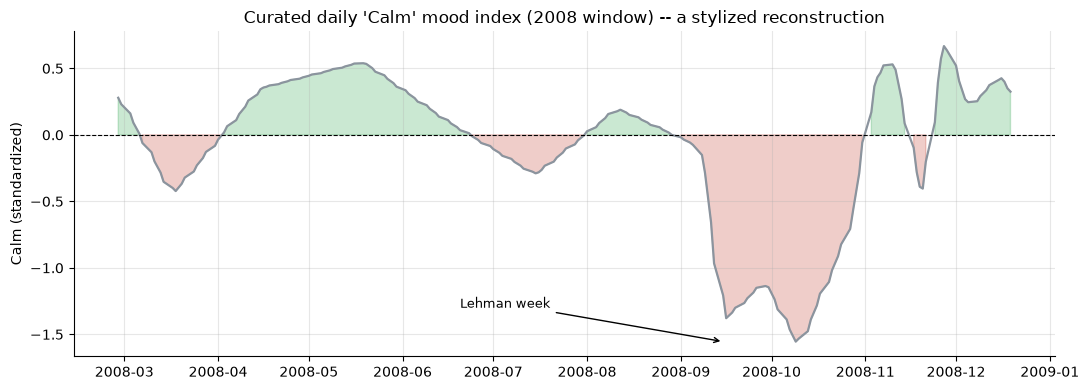

Calm index: 212 business days, range [-1.55, 0.67]


In [3]:
calm = data.calm_index()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(calm.index, calm.values, color=GREY, lw=1.6)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.fill_between(calm.index, calm.values, 0, where=(calm.values >= 0), color=GREEN, alpha=.25)
ax.fill_between(calm.index, calm.values, 0, where=(calm.values < 0),  color=RED,   alpha=.25)
ax.set_title("Curated daily 'Calm' mood index (2008 window) -- a stylized reconstruction")
ax.set_ylabel("Calm (standardized)")
ax.annotate("Lehman week", xy=(pd.Timestamp("2008-09-15"), calm.min()),
            xytext=(pd.Timestamp("2008-06-20"), -1.3), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="black"))
plt.tight_layout(); plt.savefig("../docs/calm_index.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"Calm index: {len(calm)} business days, range [{calm.min():.2f}, {calm.max():.2f}]")


## Does yesterday's Calm forecast today's return?

The heart of Bollen's claim: **Calm leads the market**. We regress the next day's
return on today's Calm and look at the slope's *t*-statistic. The desk bar for "real"
is |*t*| >= 2.


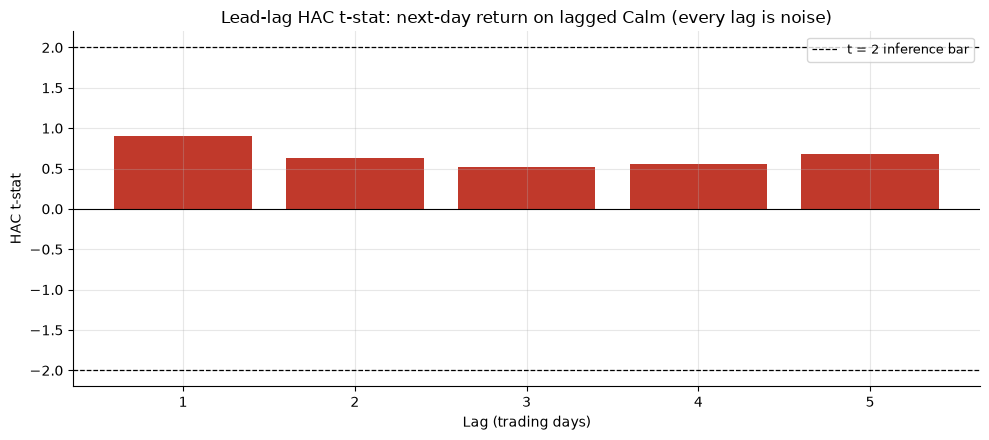

Lag-1 slope HAC t = +0.90  -- nowhere near the t>=2 bar.
Sweeping 5 lags raises the bar to |t| ~ 2.58 (Bonferroni); nothing clears it.


In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
if HAVE_REAL:
    lags = sweep["lag"].astype(int).tolist()
    tstats = sweep["tstat"].tolist()
else:
    lags = [1, 2, 3, 4, 5]
    tstats = [R["t1"], R["t2"], R["t3"], R["t4"], R["t5"]]
colors = [GREEN if abs(t) >= 2 else RED for t in tstats]
ax.bar([str(L) for L in lags], tstats, color=colors)
ax.axhline(2.0,  color="black", ls="--", lw=0.9, label="t = 2 inference bar")
ax.axhline(-2.0, color="black", ls="--", lw=0.9)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Lead-lag HAC t-stat: next-day return on lagged Calm (every lag is noise)")
ax.set_xlabel("Lag (trading days)"); ax.set_ylabel("HAC t-stat")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"Lag-1 slope HAC t = +{R['t1']:.2f}  -- nowhere near the t>=2 bar.")
print(f"Sweeping 5 lags raises the bar to |t| ~ {R['bonf_bar']:.2f} (Bonferroni); nothing clears it.")


## The base-rate trap: "51% accuracy" is not 87%

A binary "up tomorrow?" rule looks good simply because **the market drifts up most
days**. The honest comparison is against the *unconditional* up-rate, not a coin flip.


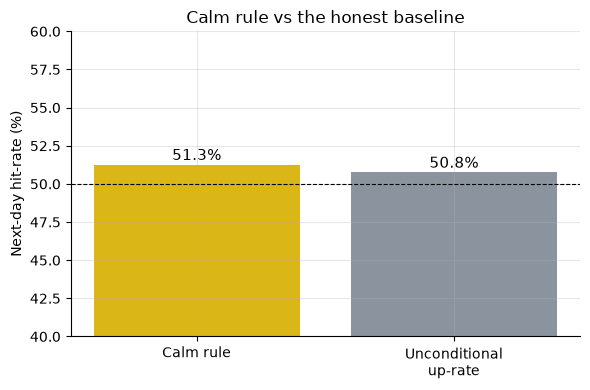

Edge over baseline: +0.5 pts. Bollen's '86.7%' does not survive.


In [5]:
if HAVE_REAL:
    hr = st.directional_hitrate(df_real, lookback=20)
    hit, uncond = hr["hit_rate"]*100, hr["uncond_up_rate"]*100
else:
    hit, uncond = R["hit_rate"], R["uncond_up"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Calm rule", "Unconditional\nup-rate"], [hit, uncond], color=[AMBER, GREY])
ax.axhline(50, color="black", ls="--", lw=0.8)
ax.set_ylim(40, 60); ax.set_ylabel("Next-day hit-rate (%)")
ax.set_title("Calm rule vs the honest baseline")
for i, v in enumerate([hit, uncond]):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=11)
plt.tight_layout(); plt.show()
print(f"Edge over baseline: +{hit-uncond:.1f} pts. Bollen's '86.7%' does not survive.")


## "But the long-short rule makes 48%/yr!" -- the 2008 crash trap

A long-short version of the Calm rule *looks* spectacular -- but only because the test
window **is the 2008 crash**. Any rule that ends up net-short into a -43%/yr panic mints
money for a reason that has nothing to do with Twitter. And it *still* fails the *t* >= 2
bar.


In [6]:
print("Trading rule over the 2008 window (1-day execution lag, costs on NAV):")
print(f"  Long/flat : {R['long_net_ann']:+.1f}%/yr net  HAC t = {R['long_net_t']:+.2f}   (flat)")
print(f"  Long/short: {R['ls_net_ann']:+.1f}%/yr net  HAC t = {R['ls_net_t']:+.2f}   (looks great...)")
print(f"  Buy & hold: {R['bh_ann']:+.1f}%/yr        HAC t = {R['bh_t']:+.2f}   (<- the crash)")
print()
print(f"The +48%/yr is a net-short-into-the-crash artefact, NOT a mood signal,")
print(f"and t = {R['ls_net_t']:.2f} does not clear the inference bar anyway.")


Trading rule over the 2008 window (1-day execution lag, costs on NAV):
  Long/flat : +3.2%/yr net  HAC t = +0.14   (flat)
  Long/short: +48.1%/yr net  HAC t = +1.25   (looks great...)
  Buy & hold: -43.1%/yr        HAC t = -1.18   (<- the crash)

The +48%/yr is a net-short-into-the-crash artefact, NOT a mood signal,
and t = 1.25 does not clear the inference bar anyway.


## The bottom line for the curious

The Twitter-mood story is a textbook **mirage**:

- The lead-lag slope is *t* = 0.90 -- pure noise; a permutation null swallows it (*p* = 0.35).
- The "87% accuracy" collapses to a 51.3% hit-rate, +0.5 pts over the base rate.
- The only profitable trade is a 2008-crash artefact that doesn't clear *t* >= 2.
- And the window is only ~10 trading months (n = 207) -- far too small to detect a
  1-3 day effect even if one existed.

The famous replication (Lachanski & Pav 2017) reached the same conclusion: the result
does not hold up. This is a **None / Mirage**.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*